In [0]:
# ============================================================
# Notebook 5
# Semantic Model Comparison
# Numeric Crypto Features vs Numeric + Semantic Features
# ============================================================

from pyspark.sql import functions as F

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight

In [0]:

# ============================================================
# 1. Load semantic feature table
# ============================================================

df = spark.table(
    "hackathon.shared_datasets.fraud_busters_semantic_features"
)

print(f"Rows: {df.count():,}")
print(f"Columns: {len(df.columns)}")

display(df.limit(5))


Rows: 1,000
Columns: 29


label,narrative,price_change_pct,social_mention_spike_x,timestamp,token,top10_holder_pct,tx_id,unique_buy_wallets,volume_spike_x,narrative_length,word_count,kw_wallet,kw_exchange,kw_liquidity,kw_deployer,kw_supply,kw_coordinated,kw_social,kw_campaign,kw_buying,kw_selling,kw_cluster,kw_active_wallets,pump_dump_flag,rug_pull_flag,coordination_flag,wallet_activity_flag,insider_flag
fraud,Anonymous channel activity signalled entry and KRUX spiked rapidly; 69% of supply moved toward exchange deposit addresses shortly after the rally.,177,19,2026-03-01T06:05:00.000Z,KRUX,59,TX00001,1506,65,146,21,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
fraud,"A low-liquidity OBLIX pool repriced after a large buy sequence, followed by rapid distribution across 55 newly active wallets.",284,18,2026-03-01T12:48:00.000Z,OBLIX,69,TX00002,488,50,126,19,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0
fraud,Anonymous channel activity signalled entry and GLIMR spiked rapidly; 41% of supply moved toward exchange deposit addresses shortly after the rally.,522,16,2026-03-01T20:38:00.000Z,GLIMR,60,TX00003,1773,45,147,21,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
fraud,"A cluster of recently created wallets accumulated 31% of FENRA supply, then sold in a coordinated 25-minute window.",578,15,2026-03-02T05:04:00.000Z,FENRA,69,TX00004,2261,20,115,18,1,0,0,0,1,1,0,0,0,0,1,0,0,0,1,1,0
fraud,Liquidity tied to original deployer wallets was withdrawn shortly after a scripted social campaign accelerated retail buying in ZYNC.,503,19,2026-03-02T08:10:00.000Z,ZYNC,54,TX00005,1565,32,133,19,1,0,1,1,0,0,1,1,1,0,0,0,0,1,0,1,0


In [0]:

# ============================================================
# 2. Check available columns
# ============================================================

print("Available columns:")
for c in df.columns:
    print(c)


Available columns:
label
narrative
price_change_pct
social_mention_spike_x
timestamp
token
top10_holder_pct
tx_id
unique_buy_wallets
volume_spike_x
narrative_length
word_count
kw_wallet
kw_exchange
kw_liquidity
kw_deployer
kw_supply
kw_coordinated
kw_social
kw_campaign
kw_buying
kw_selling
kw_cluster
kw_active_wallets
pump_dump_flag
rug_pull_flag
coordination_flag
wallet_activity_flag
insider_flag


In [0]:

# ============================================================
# 3. Create target variable
# ============================================================

if "isFraud" not in df.columns:
    df = df.withColumn(
        "isFraud",
        F.when(F.lower(F.col("label")) == "fraud", 1).otherwise(0)
    )

display(
    df.groupBy("isFraud")
      .count()
      .orderBy("isFraud")
)


isFraud,count
0,400
1,600


In [0]:

# ============================================================
# 4. Numeric crypto features
# ============================================================

numeric_crypto_features = [
    "price_change_pct",
    "volume_spike_x",
    "social_mention_spike_x",
    "top10_holder_pct",
    "unique_buy_wallets"
]

numeric_crypto_features = [
    c for c in numeric_crypto_features
    if c in df.columns
]

print("Numeric crypto features:")
print(numeric_crypto_features)


Numeric crypto features:
['price_change_pct', 'volume_spike_x', 'social_mention_spike_x', 'top10_holder_pct', 'unique_buy_wallets']


In [0]:

# ============================================================
# 5. Semantic text-derived features
# ============================================================

semantic_base_features = [
    "narrative_length",
    "word_count",
    "risk_keyword_count",
    "semantic_risk_score"
]

semantic_base_features = [
    c for c in semantic_base_features
    if c in df.columns
]

keyword_features = [
    c for c in df.columns
    if c.startswith("kw_")
]

flag_features = [
    c for c in df.columns
    if c.endswith("_flag")
]

semantic_features = (
    semantic_base_features
    + keyword_features
    + flag_features
)

# Remove duplicates while preserving order
semantic_features = list(dict.fromkeys(semantic_features))

print("Semantic features:")
for c in semantic_features:
    print(c)

print(f"\nNumber of semantic features: {len(semantic_features)}")


Semantic features:
narrative_length
word_count
kw_wallet
kw_exchange
kw_liquidity
kw_deployer
kw_supply
kw_coordinated
kw_social
kw_campaign
kw_buying
kw_selling
kw_cluster
kw_active_wallets
pump_dump_flag
rug_pull_flag
coordination_flag
wallet_activity_flag
insider_flag

Number of semantic features: 19


In [0]:

# ============================================================
# 6. Define experiments
# ============================================================

# Model B: Numeric crypto indicators only
features_numeric_only = numeric_crypto_features

# Model C: Numeric crypto indicators + semantic text features
features_numeric_plus_semantic = (
    numeric_crypto_features
    + semantic_features
)

features_numeric_plus_semantic = list(
    dict.fromkeys(features_numeric_plus_semantic)
)

print("Model B features:")
print(features_numeric_only)

print("\nModel C features:")
print(features_numeric_plus_semantic)


Model B features:
['price_change_pct', 'volume_spike_x', 'social_mention_spike_x', 'top10_holder_pct', 'unique_buy_wallets']

Model C features:
['price_change_pct', 'volume_spike_x', 'social_mention_spike_x', 'top10_holder_pct', 'unique_buy_wallets', 'narrative_length', 'word_count', 'kw_wallet', 'kw_exchange', 'kw_liquidity', 'kw_deployer', 'kw_supply', 'kw_coordinated', 'kw_social', 'kw_campaign', 'kw_buying', 'kw_selling', 'kw_cluster', 'kw_active_wallets', 'pump_dump_flag', 'rug_pull_flag', 'coordination_flag', 'wallet_activity_flag', 'insider_flag']


In [0]:

# ============================================================
# 7. Convert to Pandas
# ============================================================

selected_cols = (
    features_numeric_plus_semantic
    + ["isFraud"]
)

pdf = (
    df.select(selected_cols)
      .toPandas()
)

print(pdf.shape)
display(pdf.head())


(1000, 25)


price_change_pct,volume_spike_x,social_mention_spike_x,top10_holder_pct,unique_buy_wallets,narrative_length,word_count,kw_wallet,kw_exchange,kw_liquidity,kw_deployer,kw_supply,kw_coordinated,kw_social,kw_campaign,kw_buying,kw_selling,kw_cluster,kw_active_wallets,pump_dump_flag,rug_pull_flag,coordination_flag,wallet_activity_flag,insider_flag,isFraud
177,65,19,59,1506,146,21,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
284,50,18,69,488,126,19,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1
522,45,16,60,1773,147,21,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
578,20,15,69,2261,115,18,1,0,0,0,1,1,0,0,0,0,1,0,0,0,1,1,0,1
503,32,19,54,1565,133,19,1,0,1,1,0,0,1,1,1,0,0,0,0,1,0,1,0,1


In [0]:

# ============================================================
# 8. Ensure all modelling features are numeric
# ============================================================

for c in features_numeric_plus_semantic:
    pdf[c] = pd.to_numeric(
        pdf[c],
        errors="coerce"
    )

pdf["isFraud"] = pdf["isFraud"].astype(int)

print(pdf.dtypes)


price_change_pct          int64
volume_spike_x            int64
social_mention_spike_x    int64
top10_holder_pct          int64
unique_buy_wallets        int64
narrative_length          int32
word_count                int32
kw_wallet                 int32
kw_exchange               int32
kw_liquidity              int32
kw_deployer               int32
kw_supply                 int32
kw_coordinated            int32
kw_social                 int32
kw_campaign               int32
kw_buying                 int32
kw_selling                int32
kw_cluster                int32
kw_active_wallets         int32
pump_dump_flag            int32
rug_pull_flag             int32
coordination_flag         int32
wallet_activity_flag      int32
insider_flag              int32
isFraud                   int64
dtype: object


In [0]:

# ============================================================
# 9. Create X and y
# ============================================================

X_numeric = pdf[features_numeric_only]

X_combined = pdf[features_numeric_plus_semantic]

y = pdf["isFraud"]

print("Numeric-only shape:", X_numeric.shape)
print("Combined shape:", X_combined.shape)


Numeric-only shape: (1000, 5)
Combined shape: (1000, 24)


In [0]:

# ============================================================
# 10. Train/test split
# ============================================================

indices = np.arange(len(pdf))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_numeric_train = X_numeric.iloc[train_idx]
X_numeric_test  = X_numeric.iloc[test_idx]

X_combined_train = X_combined.iloc[train_idx]
X_combined_test  = X_combined.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print(f"Train rows: {len(y_train):,}")
print(f"Test rows:  {len(y_test):,}")


Train rows: 700
Test rows:  300


In [0]:

# ============================================================
# 11. Model training and evaluation helper
# ============================================================

def train_and_evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test,
    model_name
):

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    # Handle class imbalance
    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train
    )

    model = HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights
    )

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    }

    print(f"ROC-AUC   : {metrics['roc_auc']:.4f}")
    print(f"PR-AUC    : {metrics['pr_auc']:.4f}")
    print(f"Precision : {metrics['precision']:.4f}")
    print(f"Recall    : {metrics['recall']:.4f}")
    print(f"F1        : {metrics['f1']:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Legitimate", "Fraud"],
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    return model, y_prob, y_pred, metrics, cm


In [0]:

# ============================================================
# 12. Model B: Numeric-only model
# ============================================================

numeric_model, numeric_prob, numeric_pred, numeric_metrics, numeric_cm = (
    train_and_evaluate_model(
        X_numeric_train,
        X_numeric_test,
        y_train,
        y_test,
        "Model B: Numeric Crypto Features Only"
    )
)


Model B: Numeric Crypto Features Only
ROC-AUC   : 1.0000
PR-AUC    : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1        : 1.0000

Classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       120
       Fraud       1.00      1.00      1.00       180

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [0]:

# ============================================================
# 13. Model C: Numeric + semantic model
# ============================================================

combined_model, combined_prob, combined_pred, combined_metrics, combined_cm = (
    train_and_evaluate_model(
        X_combined_train,
        X_combined_test,
        y_train,
        y_test,
        "Model C: Numeric + Semantic Features"
    )
)


Model C: Numeric + Semantic Features
ROC-AUC   : 1.0000
PR-AUC    : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1        : 1.0000

Classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       120
       Fraud       1.00      1.00      1.00       180

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [0]:

# ============================================================
# 14. Compare model performance
# ============================================================

results = pd.DataFrame(
    [
        numeric_metrics,
        combined_metrics
    ]
)

display(results)


model,roc_auc,pr_auc,precision,recall,f1
Model B: Numeric Crypto Features Only,1.0,1.0,1.0,1.0,1.0
Model C: Numeric + Semantic Features,1.0,1.0,1.0,1.0,1.0


In [0]:

# ============================================================
# 15. Create improvement table
# ============================================================

improvement = {}

for metric in [
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "f1"
]:

    baseline_value = numeric_metrics[metric]
    combined_value = combined_metrics[metric]

    improvement[metric] = {
        "numeric_only": baseline_value,
        "numeric_plus_semantic": combined_value,
        "absolute_improvement": combined_value - baseline_value
    }

improvement_df = pd.DataFrame(improvement).T.reset_index()

improvement_df = improvement_df.rename(
    columns={
        "index": "metric"
    }
)

display(improvement_df)


metric,numeric_only,numeric_plus_semantic,absolute_improvement
roc_auc,1.0,1.0,0.0
pr_auc,1.0,1.0,0.0
precision,1.0,1.0,0.0
recall,1.0,1.0,0.0
f1,1.0,1.0,0.0


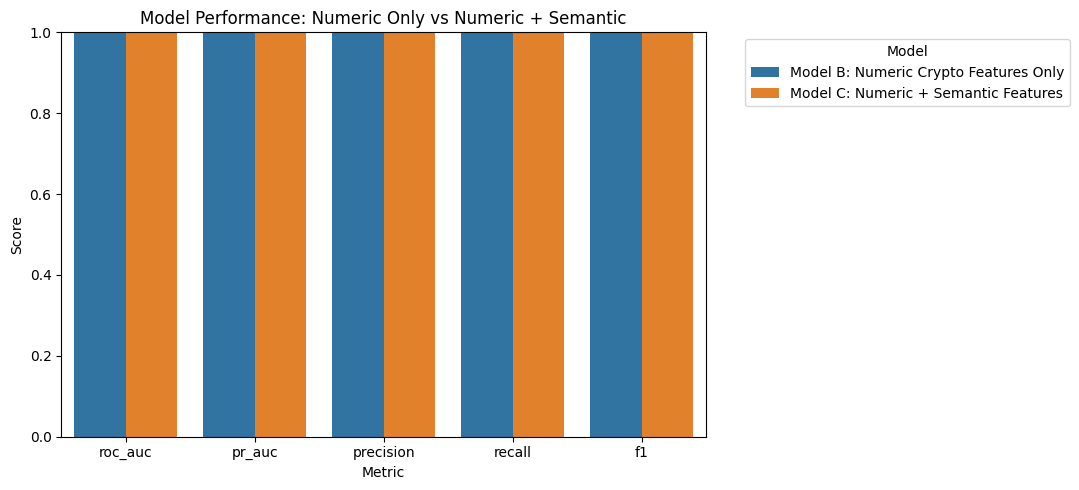

In [0]:

# ============================================================
# 16. Plot metric comparison
# ============================================================

plot_df = results.melt(
    id_vars="model",
    value_vars=[
        "roc_auc",
        "pr_auc",
        "precision",
        "recall",
        "f1"
    ],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=plot_df,
    x="metric",
    y="score",
    hue="model"
)

plt.title(
    "Model Performance: Numeric Only vs Numeric + Semantic"
)

plt.ylabel("Score")
plt.xlabel("Metric")

plt.ylim(0, 1)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


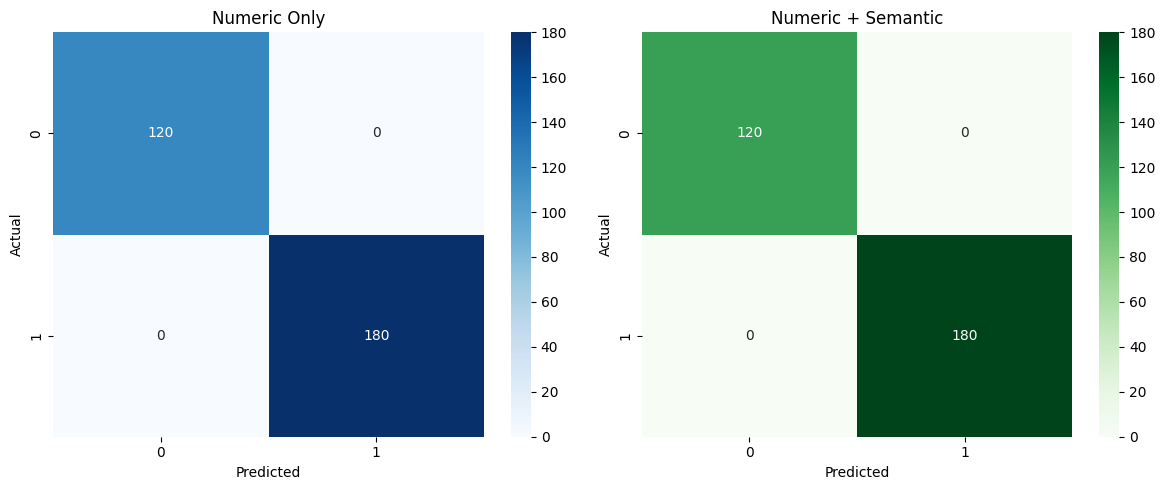

In [0]:

# ============================================================
# 17. Confusion matrices
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.heatmap(
    numeric_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Numeric Only")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    combined_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("Numeric + Semantic")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


<Figure size 700x600 with 0 Axes>

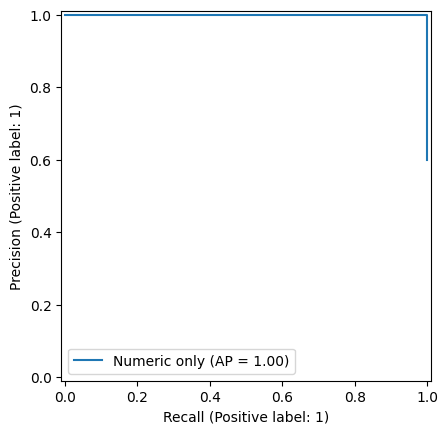

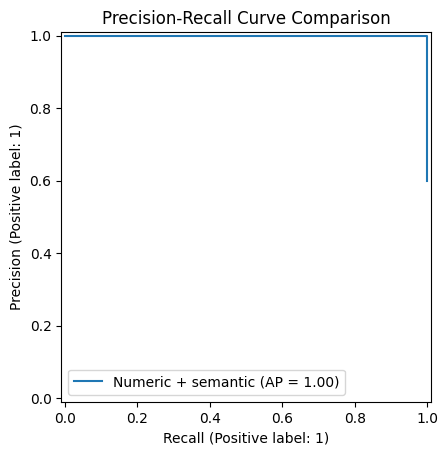

In [0]:

# ============================================================
# 18. Precision-recall curves
# ============================================================

from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    numeric_prob,
    name="Numeric only"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    combined_prob,
    name="Numeric + semantic"
)

plt.title("Precision-Recall Curve Comparison")
plt.show()


In [0]:

# ============================================================
# 19. Human review queue
# ============================================================

review_pdf = pdf.iloc[test_idx].copy()

review_pdf["actual_fraud"] = y_test.values
review_pdf["numeric_only_score"] = numeric_prob
review_pdf["combined_score"] = combined_prob
review_pdf["combined_prediction"] = combined_pred

review_pdf["semantic_score_used"] = (
    review_pdf["risk_keyword_count"]
    if "risk_keyword_count" in review_pdf.columns
    else np.nan
)

review_queue = (
    review_pdf
    .sort_values("combined_score", ascending=False)
    .head(20)
)

display(review_queue)


price_change_pct,volume_spike_x,social_mention_spike_x,top10_holder_pct,unique_buy_wallets,narrative_length,word_count,kw_wallet,kw_exchange,kw_liquidity,kw_deployer,kw_supply,kw_coordinated,kw_social,kw_campaign,kw_buying,kw_selling,kw_cluster,kw_active_wallets,pump_dump_flag,rug_pull_flag,coordination_flag,wallet_activity_flag,insider_flag,isFraud,actual_fraud,numeric_only_score,combined_score,combined_prediction,semantic_score_used
319,60,15,76,422,133,19,1,0,1,1,0,0,1,1,1,0,0,0,0,1,0,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null
352,43,20,72,1667,147,21,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.9999972687589346,0.9999972687589346,1,null
590,30,29,79,2533,126,19,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null
226,52,18,76,1847,115,18,1,0,0,0,1,1,0,0,0,0,1,0,0,0,1,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null
470,42,15,70,1987,132,20,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null
369,61,12,62,2576,121,18,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null
323,62,25,56,2525,134,19,1,0,1,1,0,0,1,1,1,0,0,0,0,1,0,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null
398,44,34,74,1176,114,18,1,0,0,0,1,1,0,0,0,0,1,0,0,0,1,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null
245,22,30,63,2189,132,20,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null
326,26,32,60,1394,121,18,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0.9999972687589346,0.9999972687589346,1,null


In [0]:

# ============================================================
# 21. Final conclusion text helper
# ============================================================

roc_change = (
    combined_metrics["roc_auc"]
    -
    numeric_metrics["roc_auc"]
)

pr_change = (
    combined_metrics["pr_auc"]
    -
    numeric_metrics["pr_auc"]
)

f1_change = (
    combined_metrics["f1"]
    -
    numeric_metrics["f1"]
)



In [0]:

review_df = df.select(
    "label",
    "narrative",
    "kw_wallet",
    "kw_liquidity",
    "kw_supply",
    "kw_coordinated",
    "kw_social"
).toPandas()

def build_explanation(row):

    reasons = []

    if row["kw_wallet"] == 1:
        reasons.append("Wallet activity detected")

    if row["kw_liquidity"] == 1:
        reasons.append("Liquidity withdrawal detected")

    if row["kw_supply"] == 1:
        reasons.append("Supply concentration observed")

    if row["kw_coordinated"] == 1:
        reasons.append("Coordinated activity present")

    if row["kw_social"] == 1:
        reasons.append("Social campaign activity detected")

    return reasons

review_df["reasons"] = review_df.apply(
    build_explanation,
    axis=1
)

display(
    review_df[
        [
            "label",
            "narrative",
            "reasons"
        ]
    ].head(10)
)


label,narrative,reasons
fraud,Anonymous channel activity signalled entry and KRUX spiked rapidly; 69% of supply moved toward exchange deposit addresses shortly after the rally.,List(Supply concentration observed)
fraud,"A low-liquidity OBLIX pool repriced after a large buy sequence, followed by rapid distribution across 55 newly active wallets.","List(Wallet activity detected, Liquidity withdrawal detected)"
fraud,Anonymous channel activity signalled entry and GLIMR spiked rapidly; 41% of supply moved toward exchange deposit addresses shortly after the rally.,List(Supply concentration observed)
fraud,"A cluster of recently created wallets accumulated 31% of FENRA supply, then sold in a coordinated 25-minute window.","List(Wallet activity detected, Supply concentration observed, Coordinated activity present)"
fraud,Liquidity tied to original deployer wallets was withdrawn shortly after a scripted social campaign accelerated retail buying in ZYNC.,"List(Wallet activity detected, Liquidity withdrawal detected, Social campaign activity detected)"
fraud,"A low-liquidity VORTX pool repriced after a large buy sequence, followed by rapid distribution across 79 newly active wallets.","List(Wallet activity detected, Liquidity withdrawal detected)"
fraud,Liquidity tied to original deployer wallets was withdrawn shortly after a scripted social campaign accelerated retail buying in MYSTR.,"List(Wallet activity detected, Liquidity withdrawal detected, Social campaign activity detected)"
fraud,"A cluster of recently created wallets accumulated 28% of KRUX supply, then sold in a coordinated 65-minute window.","List(Wallet activity detected, Supply concentration observed, Coordinated activity present)"
fraud,"A cluster of recently created wallets accumulated 36% of MYSTR supply, then sold in a coordinated 61-minute window.","List(Wallet activity detected, Supply concentration observed, Coordinated activity present)"
fraud,"A cluster of recently created wallets accumulated 34% of KRUX supply, then sold in a coordinated 23-minute window.","List(Wallet activity detected, Supply concentration observed, Coordinated activity present)"
